# Disaster Tweet Classification: Day 4 Model Improvements

## Goal
Improve the Day 3 baseline by testing stronger classical NLP models and richer TF-IDF feature settings.

## What this notebook does
1. Load the processed training data
2. Reuse the same train/validation split as Day 3
3. Run multiple controlled experiments
4. Compare models using F1, precision, recall, and accuracy
5. Save a model comparison chart
6. Identify the best model to carry forward into error analysis and tuning

## Planned experiments
- Experiment 002: TF-IDF unigrams + Logistic Regression
- Experiment 003: TF-IDF bigrams + Logistic Regression
- Experiment 004: TF-IDF bigrams + LinearSVC
- Experiment 005: TF-IDF char n-grams + Logistic Regression

In [41]:
print("Imports and Constants")

import os
import warnings
from IPython.display import display

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

UNIGRAM_RANGE = (1,1)
BIGRAM_RANGE = (1,2)
MAX_FEATURES = 10000
RANDOM_STATE = 42
TEST_SIZE = 0.2

TRAIN_PROCESSED_PATH = "../outputs/train_processed.csv"
FIGURES_DIR = "../outputs/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 250)

Imports and Constants


In [42]:
print("Load Processed Data")

df = pd.read_csv(TRAIN_PROCESSED_PATH, keep_default_na=False)
df["cleaned_text"] = df["cleaned_text"].fillna("").astype(str).str.strip()

print("Shape:", df.shape)
print("Missing cleaned_text:", df["cleaned_text"].isna().sum())
print("Empty cleaned_text:", (df["cleaned_text"] == "").sum())

display(df[["text", "cleaned_text", "target"]].head())

Load Processed Data
Shape: (7613, 13)
Missing cleaned_text: 0
Empty cleaned_text: 2


,text,cleaned_text,target
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected,resident asked shelter place notified officer evacuation shelter place order expected,1
3,"13,000 people receive #wildfires evacuation orders in California",people receive wildfire evacuation order california,1
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo ruby alaska smoke wildfire pours school,1


In [43]:
print("Train-Validation Split")

X = df["cleaned_text"]
y = df["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("Validation target distribution:")
print(y_val.value_counts(normalize=True).round(4))

Train-Validation Split
X_train shape: (6090,)
X_val shape: (1523,)
y_train shape: (6090,)
y_val shape: (1523,)
Training target distribution:
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64
Validation target distribution:
target
0    0.5706
1    0.4294
Name: proportion, dtype: float64


In [44]:
print("Baseline Reference")

results = []

results.append({
    "experiment": "Exp 001",
    "model": "MultinomialNB + TF-IDF (1,1)",
    "f1": 0.7732,
    "precision": 0.8540,
    "recall": 0.7064,
    "accuracy": 0.8221
})

Baseline Reference


In [45]:
print("Evaluate Model Helper Function")

def evaluate_model(name, pipeline, X_train, y_train, X_val, y_val, experiment_id):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    metrics = {
        "experiment": experiment_id,
        "model": name,
        "f1": f1_score(y_val, y_pred),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "accuracy": accuracy_score(y_val, y_pred)
    }

    return pipeline, y_pred, metrics

Evaluate Model Helper Function


## Experiment 002 — Logistic Regression with unigram TF-IDF

This tests whether replacing Naive Bayes with a more expressive linear classifier improves performance while keeping the same unigram TF-IDF feature space.

In [46]:
print("Logistic Regression with Unigram TF-IDF")

exp_002_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=UNIGRAM_RANGE,
        max_features=MAX_FEATURES
    )),
    ("clf", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

exp_002_pipeline, exp_002_pred, exp_002_metrics = evaluate_model(
    name="LogisticRegression + TF-IDF (1,1)",
    pipeline=exp_002_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    experiment_id="Exp 002"
)

results.append(exp_002_metrics)
pd.DataFrame([exp_002_metrics]).round(4)

Logistic Regression with Unigram TF-IDF


,experiment,model,f1,precision,recall,accuracy
0,Exp 002,"LogisticRegression + TF-IDF (1,1)",0.7769,0.8453,0.7187,0.8227


In [47]:
print("Experiment 002: Classification Report\n")
print(classification_report(y_val, exp_002_pred, digits=4))

Experiment 002: Classification Report

              precision    recall  f1-score   support

           0     0.8097    0.9010    0.8529       869
           1     0.8453    0.7187    0.7769       654

    accuracy                         0.8227      1523
   macro avg     0.8275    0.8098    0.8149      1523
weighted avg     0.8250    0.8227    0.8203      1523



## Experiment 003 — Logistic Regression with unigram + bigram TF-IDF

This tests whether phrase-level features improve performance. Disaster meaning often depends on short phrases, so bigrams may capture signal that unigrams miss.

In [48]:
print("Logistic Regression with Unigram + Bigram TF-IDF")

exp_003_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=BIGRAM_RANGE,
        max_features=50000
    )),
    ("clf", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

exp_003_pipeline, exp_003_pred, exp_003_metrics = evaluate_model(
    name="LogisticRegression + TF-IDF (1,2)",
    pipeline=exp_003_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    experiment_id="Exp 003"
)

results.append(exp_003_metrics)
pd.DataFrame([exp_003_metrics]).round(4)

Logistic Regression with Unigram + Bigram TF-IDF


,experiment,model,f1,precision,recall,accuracy
0,Exp 003,"LogisticRegression + TF-IDF (1,2)",0.7649,0.8447,0.6988,0.8155


In [49]:
print("Experiment 003: Classification Report")
print(classification_report(y_val, exp_003_pred, digits=4))

Experiment 003: Classification Report
              precision    recall  f1-score   support

           0     0.7994    0.9033    0.8482       869
           1     0.8447    0.6988    0.7649       654

    accuracy                         0.8155      1523
   macro avg     0.8221    0.8011    0.8065      1523
weighted avg     0.8189    0.8155    0.8124      1523



## Experiment 004 — LinearSVC with unigram + bigram TF-IDF

LinearSVC is a strong classical text classifier for sparse high-dimensional features and is often one of the best non-transformer baselines for short text classification.

In [50]:
exp_004_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=50000
    )),
    ("clf", LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE,
        max_iter=2000
    ))
])

exp_004_pipeline, exp_004_pred, exp_004_metrics = evaluate_model(
    name="LinearSVC + TF-IDF (1,2)",
    pipeline=exp_004_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    experiment_id="Exp 004"
)

results.append(exp_004_metrics)
pd.DataFrame([exp_004_metrics]).round(4)

,experiment,model,f1,precision,recall,accuracy
0,Exp 004,"LinearSVC + TF-IDF (1,2)",0.775,0.7923,0.7584,0.8109


In [51]:
print("Experiment 004: Classification Report\n")
print(classification_report(y_val, exp_004_pred, digits=4))

Experiment 004: Classification Report

              precision    recall  f1-score   support

           0     0.8239    0.8504    0.8369       869
           1     0.7923    0.7584    0.7750       654

    accuracy                         0.8109      1523
   macro avg     0.8081    0.8044    0.8060      1523
weighted avg     0.8103    0.8109    0.8103      1523



## Experiment 005: Character n-gram TF-IDF

Character n-grams can help with noisy spelling, partial words, and subword patterns that word-level features may miss.
This is a useful add-on experiment, but it is still secondary to the core unigram/bigram comparison.

In [52]:
exp_005_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 4),
        max_features=50000
    )),
    ("clf", LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

exp_005_pipeline, exp_005_pred, exp_005_metrics = evaluate_model(
    name="LogisticRegression + Char TF-IDF (2,4)",
    pipeline=exp_005_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    experiment_id="Exp 005"
)

results.append(exp_005_metrics)
pd.DataFrame([exp_005_metrics]).round(4)

,experiment,model,f1,precision,recall,accuracy
0,Exp 005,"LogisticRegression + Char TF-IDF (2,4)",0.7634,0.8121,0.7202,0.8083


In [53]:
print("Experiment 005: Classification Report\n")
print(classification_report(y_val, exp_005_pred, digits=4))

Experiment 005: Classification Report

              precision    recall  f1-score   support

           0     0.8059    0.8746    0.8389       869
           1     0.8121    0.7202    0.7634       654

    accuracy                         0.8083      1523
   macro avg     0.8090    0.7974    0.8011      1523
weighted avg     0.8086    0.8083    0.8064      1523



## Compare all experiments

Now I compare all model runs side by side using the same validation split and the same metrics.
The primary metric is F1 score, because the competition and project evaluation are both centered on balancing precision and recall.

In [54]:
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["experiment", "model", "f1", "precision", "recall", "accuracy"])
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

,experiment,model,f1,precision,recall,accuracy
0,Exp 002,"LogisticRegression + TF-IDF (1,1)",0.7769,0.8453,0.7187,0.8227
1,Exp 004,"LinearSVC + TF-IDF (1,2)",0.7750,0.7923,0.7584,0.8109
2,Exp 001,"MultinomialNB + TF-IDF (1,1)",0.7732,0.8540,0.7064,0.8221
3,Exp 003,"LogisticRegression + TF-IDF (1,2)",0.7649,0.8447,0.6988,0.8155
4,Exp 005,"LogisticRegression + Char TF-IDF (2,4)",0.7634,0.8121,0.7202,0.8083


In [55]:
print("Improvement vs Baseline")

baseline_f1 = results_df.loc[results_df["experiment"] == "Exp 001", "f1"].values[0]

comparison_df = results_df.copy()
comparison_df["f1_gain_vs_baseline"] = (comparison_df["f1"] - baseline_f1).round(4)
comparison_df["precision_gain_vs_baseline"] = (
    comparison_df["precision"] - 0.8540
).round(4)
comparison_df["recall_gain_vs_baseline"] = (
    comparison_df["recall"] - 0.7064
).round(4)

display(comparison_df.round(4))

Improvement vs Baseline


,experiment,model,f1,precision,recall,accuracy,f1_gain_vs_baseline,precision_gain_vs_baseline,recall_gain_vs_baseline
0,Exp 002,"LogisticRegression + TF-IDF (1,1)",0.7769,0.8453,0.7187,0.8227,0.0037,-0.0087,0.0123
1,Exp 004,"LinearSVC + TF-IDF (1,2)",0.7750,0.7923,0.7584,0.8109,0.0018,-0.0617,0.0520
2,Exp 001,"MultinomialNB + TF-IDF (1,1)",0.7732,0.8540,0.7064,0.8221,0.0000,0.0000,0.0000
3,Exp 003,"LogisticRegression + TF-IDF (1,2)",0.7649,0.8447,0.6988,0.8155,-0.0083,-0.0093,-0.0076
4,Exp 005,"LogisticRegression + Char TF-IDF (2,4)",0.7634,0.8121,0.7202,0.8083,-0.0098,-0.0419,0.0138


Model Comparison Chart


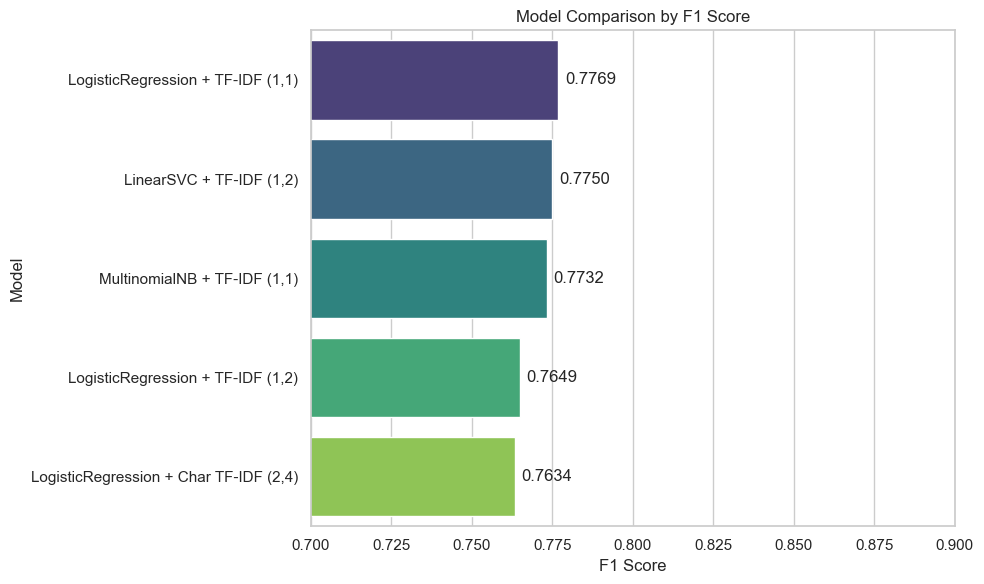

In [56]:
print("Model Comparison Chart")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="f1", y="model", palette="viridis")
plt.title("Model Comparison by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0.70, 0.90)

for index, row in results_df.iterrows():
    plt.text(row["f1"] + 0.002, index, f"{row['f1']:.4f}", va="center")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
print("Best Model")

best_row = results_df.iloc[0]

print("Best model:")
display(best_row.to_frame().T)

Best Model
Best model:


,experiment,model,f1,precision,recall,accuracy
0,Exp 002,"LogisticRegression + TF-IDF (1,1)",0.77686,0.845324,0.718654,0.822718


In [58]:
prediction_lookup = {
    "Exp 002": exp_002_pred,
    "Exp 003": exp_003_pred,
    "Exp 004": exp_004_pred,
    "Exp 005": exp_005_pred
}

best_experiment = best_row["experiment"]
best_predictions = prediction_lookup[best_experiment]

best_val_results_df = pd.DataFrame({
    "text": X_val.values,
    "true_label": y_val.values,
    "pred_label": best_predictions
})

best_val_results_df["correct"] = best_val_results_df["true_label"] == best_val_results_df["pred_label"]

display(best_val_results_df.sample(15, random_state=RANDOM_STATE))

,text,true_label,pred_label,correct
566,deadpool already one favourite marvel character know wear red suit bad guy tell bleeding,0,0,True
1101,rt homeless vulnerable north texas heat wave,1,1,True
1475,would great mbiwa flattened little rat,0,0,True
1178,fascinating pic inside north korea propaganda devastation people living life,0,1,False
1009,hollywood movie trapped miner released chile zippednews,0,0,True
433,da one mtvsummerstar videoveranomtv mtvhottest britney spear lana del rey,0,0,True
855,building fire time business meeting thestrain,1,1,True
1493,heat advisory effect pm pm thursday building heat wave increasing humidity lawx,1,1,True
1032,burst actual tear joy cain survived summerfate,0,0,True
1079,dating someone let smoke leave date someone also smoke trust,0,0,True


In [59]:
for _, row in results_df.iterrows():
    print(
        f"{row['experiment']} | {row['model']} | "
        f"F1={row['f1']:.4f} | Precision={row['precision']:.4f} | "
        f"Recall={row['recall']:.4f} | Accuracy={row['accuracy']:.4f}"
    )

Exp 002 | LogisticRegression + TF-IDF (1,1) | F1=0.7769 | Precision=0.8453 | Recall=0.7187 | Accuracy=0.8227
Exp 004 | LinearSVC + TF-IDF (1,2) | F1=0.7750 | Precision=0.7923 | Recall=0.7584 | Accuracy=0.8109
Exp 001 | MultinomialNB + TF-IDF (1,1) | F1=0.7732 | Precision=0.8540 | Recall=0.7064 | Accuracy=0.8221
Exp 003 | LogisticRegression + TF-IDF (1,2) | F1=0.7649 | Precision=0.8447 | Recall=0.6988 | Accuracy=0.8155
Exp 005 | LogisticRegression + Char TF-IDF (2,4) | F1=0.7634 | Precision=0.8121 | Recall=0.7202 | Accuracy=0.8083


## Day 4 Observations

### 1. Best overall model
- The best overall model in Day 4 was **Logistic Regression + TF-IDF (1,1)** with **F1 = 0.7769**, **precision = 0.8453**, **recall = 0.7187**, and **accuracy = 0.8227**.
- This slightly outperformed the Day 3 Naive Bayes baseline, which had **F1 = 0.7732**.
- The improvement is real, but small, which means the unigram TF-IDF representation is already fairly strong.

### 2. Most recall-friendly model
- **LinearSVC + TF-IDF (1,2)** achieved **F1 = 0.7750** and the **highest recall = 0.7584** among all tested models.
- This model is slightly weaker than Exp 002 on overall F1, but it catches more real disaster tweets.
- That makes it an important alternative depending on whether recall is prioritized over precision.

### 3. Effect of bigrams
- Adding bigrams to Logistic Regression did **not** improve performance in this run.
- `LogisticRegression + TF-IDF (1,2)` scored lower than the unigram Logistic Regression model.
- This suggests that, for the current preprocessing setup and feature limits, bigrams added complexity without enough additional signal.

### 4. Character n-grams
- The character n-gram model also did not beat the strongest word-level models.
- It produced competitive recall, but lower F1 than both Exp 002 and Exp 004.
- For this dataset, word-level TF-IDF remains the stronger baseline direction so far.

### 5. Main takeaway
- The performance gap between the top models is small, which means further gains will likely come from better tuning and deeper error analysis rather than just swapping classifiers.
- Day 5 should focus on understanding where the best models fail, especially figurative language, vague phrasing, and ambiguous disaster vocabulary.
- Day 6 tuning should likely start with **Exp 002** and optionally compare against **Exp 004** if recall becomes the priority.